# Imports

In [44]:
import scipy.io as sio
import numpy as np
import pandas as pd
from pathlib import Path
import re
from sklearn import tree
from matplotlib import pyplot as plt

In [2]:

CATCH22 = [
    'DN_HistogramMode_5', 'DN_HistogramMode_10',
    'SB_BinaryStats_mean_longstretch1',
    'DN_OutlierInclude_p_001_mdrmd', 'DN_OutlierInclude_n_001_mdrmd',
    'CO_f1ecac', 'CO_FirstMin_ac',
    'SP_Summaries_welch_rect_area_5_1', 'SP_Summaries_welch_rect_centroid',
    'FC_LocalSimple_mean3_stderr',
    'CO_trev_1_num', 'CO_HistogramAMI_even_2_5',
    'IN_AutoMutualInfoStats_40_gaussian_fmmi',
    'MD_hrv_classic_pnn40',
    'SB_BinaryStats_diff_longstretch0', 'SB_MotifThree_quantile_hh',
    'FC_LocalSimple_mean1_tauresrat',
    'CO_Embed2_Dist_tau_d_expfit_meandiff',
    'SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1',
    'SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1',
    'SB_TransitionMatrix_3ac_sumdiagcov',
    'PD_PeriodicityWang_th0.01',
]


# Goals
Learn fundamentals of feature selection - for classification task.
   
   - To be able to **replicate the pipeline for anomaly detection**. Pre-computed feature based models make it easier reason about the model results - more interpretability - more trust from operators/engineers in model results


# Feature Selection Pipeline for Classification task
- exactly replicate catch22 paper but with tsfresh features
- Step 1: exactly reproduce catch22 paper's results
- Step 2: re-org code
- Step 3: apply the pipeline to tsfresh paper

## Data Load: UCR Clasification data
- load pre-saved features with raw data characterizing features removed
  - does prefiltering even matter? can the rest of the pipeline remove the raw features
- these features are missing two autocorrelation related features - which can be computed from raw time series
  
*C22 paper*: "Features were calculated in Matlab 2017a (a product of The MathWorks, Natick, MA) using hctsa v0.97."

In [3]:

TEST_DATASETS = ["ShapeletSim", "Plane", "CinCECGtorso"]

In [4]:

all_tasks = pd.read_parquet(
    Path("../datasets/ucr_hctsa_raw_removed.parquet"),
    filters=[("dataset_name", "in", TEST_DATASETS)],
)

In [5]:
all_tasks["dataset_name"].unique()

<ArrowStringArray>
['CinCECGtorso', 'Plane', 'ShapeletSim']
Length: 3, dtype: str

In [6]:
all_tasks.shape

(1830, 6894)

## Normalize Features: MinMax
- *C22 paper:* For each dataset, each feature was linearly rescaled to the unit interval. 

- Features with zero range (constant across all time series in a dataset) become NaN

In [7]:
feature_cols = [c for c in all_tasks.columns if c not in ('label', 'dataset_name')]

def normalize_features(group):
    feat = group[feature_cols].copy()
    min_vals = feat.min()
    range_vals = feat.max() - min_vals
    result = group.copy()
    result[feature_cols] = (feat - min_vals) / range_vals
    # result['dataset_name'] = group.name
    return result

all_tasks_n = all_tasks.groupby('dataset_name').apply(normalize_features).copy()
print(f"Shape: {all_tasks.shape}")

Shape: (1830, 6894)


In [8]:
all_tasks_n = all_tasks_n.reset_index().drop(columns='level_1')
all_tasks_n.shape

(1830, 6894)

## Prefiltering - Remove Invalid Valued Features
- *C22 paper*: Algorithms that produced special-valued outputs on at least one time series,
  in more than 80% of our datasets were excluded: a total of 2101 features

In [10]:

def has_invalid(col):
    return col.isna().any() | np.isinf(col).any()

invalid_dataset_count = (
    all_tasks.groupby('dataset_name')[feature_cols]
    .apply(lambda grp: grp.apply(has_invalid))
    .sum()
)

In [11]:

num_datasets = all_tasks["dataset_name"].nunique()
survivors = invalid_dataset_count[invalid_dataset_count < 0.8 * num_datasets]

# Quality: % of datasets where the feature is fully valid
quality = 1 - survivors / num_datasets
print(f"Median: {quality.median():.1%}")
print(f"Worst:  {quality.min():.1%}")
print(f"≥99%:   {(quality >= 0.99).mean():.1%} of survivors")

Median: 100.0%
Worst:  33.3%
≥99%:   87.0% of survivors


In [12]:


in_survivors = [f for f in CATCH22 if f in survivors.index]
missing = [f for f in CATCH22 if f not in survivors.index]
not_in_features = [f for f in CATCH22 if f not in feature_cols]

print(f"In survivors: {len(in_survivors)}/22")
print(f"Missing from survivors: {missing}")
print(f"Not in feature set at all: {not_in_features}")

In survivors: 20/22
Missing from survivors: ['CO_f1ecac', 'CO_FirstMin_ac']
Not in feature set at all: ['CO_f1ecac', 'CO_FirstMin_ac']


In [13]:
# all tasks with raw features removed
# normalized features and features with invalid values prefiltered 
all_tasks_n_pf = all_tasks_n[list(survivors.index) + ["label", "dataset_name"]]

In [14]:
all_tasks_n.shape

(1830, 6894)

## Accuracy estimation


$N_{\text{CV}} = \min \lbrace 10, \max \lbrack 2, \min_{k=1}^{N_c} ( \sum_{l=1}^{N_{\text{TS}}} \boldsymbol{1}(y_l = k) ) \rbrack \rbrace$

$a_{i,j}(y, \hat{y}, w) = \frac{1}{\sum_{l=1}^{N_{\text{TS}}} w_l} \sum_{l=1}^{N_{\text{TS}}} \mathbf{1}(\hat{y}_l = y_l) w_l$

where $w_l = 1 / \sum_{m=1}^{N_{\text{TS}}} \mathbf{1}(y_m = y_l)$


In [16]:
def num_of_folds(tasks: pd.DataFrame):
    num_ts = tasks.groupby(["dataset_name", "label"]).size().reset_index(name='sample_size')
    num_folds = num_ts.groupby(["dataset_name"])["sample_size"].min().reset_index(name="nfolds")
    num_folds["nfolds"] =num_folds["nfolds"].clip(2,10)
    return num_folds
nfolds = num_of_folds(all_tasks_n_pf)
nfolds

,dataset_name,nfolds
0,CinCECGtorso,10
1,Plane,10
2,ShapeletSim,10


In [17]:
from sklearn.metrics import balanced_accuracy_score

def accuracy_class_balanced(y_true: np.array, y_predict: np.array):
    y_true = np.asarray(y_true)
    y_predict = np.asarray(y_predict)
    classes, counts = np.unique(y_true, return_counts=True)
    # map each sample to its class weight via index lookup (classes are sorted)
    w = 1.0 / counts[np.searchsorted(classes, y_true)]
    accuracy = np.sum((y_true == y_predict) * w) / np.sum(w)
    return accuracy

assert accuracy_class_balanced([1,1,2], [2,2,2]) == balanced_accuracy_score([1,1,2], [2,2,2])
accuracy_class_balanced([1,1,2], [2,2,2])

np.float64(0.5)


## Statistical Prefiltering 
 *Example Dataset with two features*

  Dataset: ShapeletSim The paper discusses this dataset extensively (p.18-19, Fig. 7A). The two classes have no reliable shape difference in the time domain — both look like noise — but are clearly distinguished by their frequency content (Welch power spectra differ visibly between classes).
  - See (Fig. 8A, p.20-21)

  Statistically significant feature:
  - SB_BinaryStats_diff_longstretch0 — measures the longest run of consecutive decreasing increments. It "enables a perfect separation of the two classes because time series of the 'triangle' class vary on a slower timescale than 'noise' time series." In Fig. 8A you can see the two classes are cleanly
   separated along this axis.

  Essentially random (consistent with chance):
  - DN_HistogramMode_5 — the y-axis of the same Fig. 8A scatter plot. The two classes overlap completely on this feature (both span roughly -1 to 1.5), showing it has no discriminative power on ShapeletSim. This makes sense: both 'noise' and 'triangle' classes have similar value distributions, so the
  mode of the histogram tells you nothing about class membership.

### Null Distribution Construction
Given the size and diversity of features in hctsa, we first wanted to deter-
mine whether some features exhibited performance consistent with chance on
this set of classification tasks. To estimate a p-value for each feature on each
classification task, we generated null accuracy distributions, as i,j (superscript
s incidating ‘shuffeled’), using a permutation-based procedure that involved
1000 repeats of the classification procedure using randomly shuffled class la-
bels, shown in Fig. 1A. From visual inspection, the null distributions were
mostly unimodal and approximately normally distributed and, as expected,
had higher variance on datasets with fewer time series. Accordingly, we esti-
mated a p-value for each feature-task combination by fitting a Gaussian prob-
ability distribution to the null accuracy distributions, as i,j , as the probability
of the shuffled accuracy being higher than the observed accuracy.

- do stratified cv
- generalize across datasets
  - multiple tasks test
- loop over all features

In [51]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import make_scorer

TEST_FEATURES = ["SB_BinaryStats_diff_longstretch0", "DN_HistogramMode_5"]
features = [TEST_FEATURES[1]]
scorer = make_scorer(accuracy_class_balanced)

null_dist = {} 
actual_scores = {}

for (dname,), data in all_tasks_n_pf.groupby(["dataset_name"]):
    null_scores = []
    n_cv = nfolds.loc[nfolds['dataset_name'] == dname, 'nfolds'].values[0]
    X = data[features]
    y = data['label']
    cv = StratifiedKFold(n_splits=n_cv, shuffle=True, random_state=42)
    stump = tree.DecisionTreeClassifier(max_depth=1)
    scores = cross_val_score(stump, X, y, cv=cv, scoring=scorer)
    actual_scores[dname] = scores.mean()

    for exp in range(1000):
        shuffled_y = np.random.permutation(y)

        cv = StratifiedKFold(n_splits=n_cv, shuffle=True, random_state=42)
        stump = tree.DecisionTreeClassifier(max_depth=1)
        scores = cross_val_score(stump, X, shuffled_y, cv=cv, scoring=scorer)
        null_scores.append(scores.mean())
        
        # print(f"Folds: {n_cv}, Mean: {scores.mean():.4f}, Std: {scores.std():.4f}")
        # print(f"Per-fold: {scores}")
    null_dist[dname] = null_scores

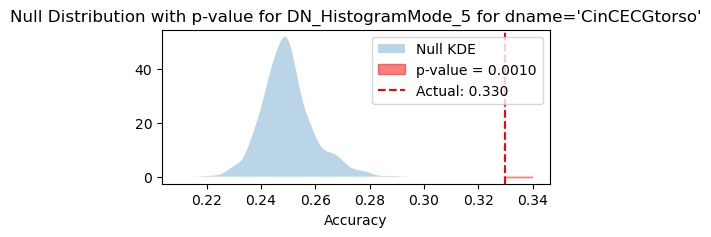

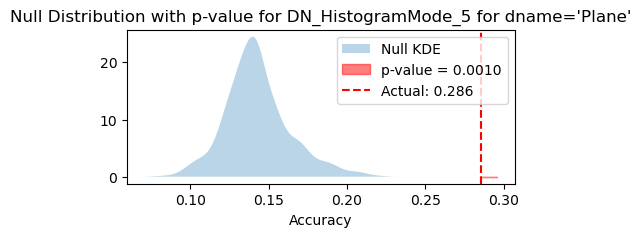

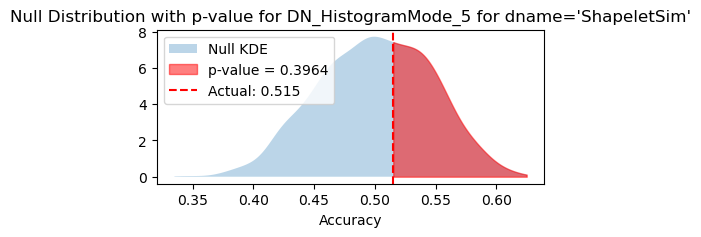

In [63]:

n_permutations = 1000  # whatever you used
   
from scipy.stats import gaussian_kde
all_p_values = {}
for dname, actual_score in actual_scores.items():
    kde = gaussian_kde(null_dist[dname])
    # p-value = P(score >= actual_score) under null distribution
    p_value = kde.integrate_box_1d(actual_score, np.inf)
    p_value = np.maximum(p_value, 1 / (n_permutations + 1))
    all_p_values[(features[0], dname)] = p_value

    fig, ax = plt.subplots(figsize=(5, 2))
    x_grid = np.linspace(min(null_dist[dname]) - 0.01, max(max(null_dist[dname]), actual_score) + 0.01, 500)
    ax.fill_between(x_grid, kde(x_grid), alpha=0.3, label='Null KDE')
    ax.fill_between(x_grid[x_grid >= actual_score], kde(x_grid[x_grid >= actual_score]), 
                    alpha=0.5, color='red', label=f'p-value = {p_value:.4f}')
    ax.axvline(actual_score, color='red', linestyle='--', label=f'Actual: {actual_score:.3f}')
    ax.set_xlabel('Accuracy')
    ax.set_title(f'Null Distribution with p-value for {features[0]} for {dname=}')
    ax.legend()

### Multiple Tests Comnbining
*C22 Paper:* "To combine p-values for a given feature across all classification tasks, 
- used Fisher’s method [10] and 
- corrected for multiple hypothesis testing across
features using the Holm-Bonferroni method [17] at a significance level of 0.05."

 **Fisher Test**
The problem it solves

  You ran the same statistical test (e.g., "is feature X useful for classification?") across many independent tasks. Now you have a collection of p-values for the same feature:

  Feature "mean_abs_change":
    Task 1 → p = 0.03
    Task 2 → p = 0.12
    Task 3 → p = 0.08
    Task 4 → p = 0.45
    ...

  No single p-value is the full picture. You want one combined answer: is this feature statistically useful overall?

  The core intuition

  Under the null hypothesis (feature is useless), p-values are uniformly distributed on [0, 1]. That means -log(p) follows an exponential distribution, and -2 * log(p) follows a chi-squared distribution with 2 degrees of freedom.

  Fisher's insight: if you sum independent chi-squared variables, you get another chi-squared variable. So for k independent tests:

  X² = -2 * Σ log(pᵢ)      (sum over k tasks)

  This follows a chi-squared distribution with 2k degrees of freedom under the null.

  Why it works intuitively

  - Small p-values → large -log(p) → inflates the sum
  - If many tasks give small p-values, the sum becomes improbably large under the null
  - Even if no single task is "significant" alone, consistent evidence across tasks accumulates

  In your example: p = 0.03, 0.12, 0.08, 0.45 — none are slam dunks individually, but together they might be.

In [61]:
all_p_values.values()

dict_values([np.float64(0.0), np.float64(0.0), np.float64(0.3964482111246654)])

In [65]:
from scipy.stats import combine_pvalues                                                                                                                                                                                                                    
                                                                                                                                                                                                                                                             
  # p_values_for_feature = array of p-values across all classification tasks                                                                                                                                                                                 
statistic, combined_p = combine_pvalues(list(all_p_values.values()), method='fisher')

Holm-Bonferroni Correction

  The problem

  You just ran Fisher's test for every feature (say 7000+ hctsa features). Each one gives a combined p-value. If you threshold at 0.05, you'd expect ~350 false positives purely by chance (5% of 7000). That's the multiple hypothesis testing problem.

  How it works

  1. Sort all your combined p-values from smallest to largest
  2. Compare each one against a progressively relaxing threshold:
    - Smallest p-value must beat 0.05 / N (N = number of features)
    - Second smallest must beat 0.05 / (N-1)
    - Third must beat 0.05 / (N-2)
    - ...and so on
  3. Stop at the first feature that fails its threshold. That feature and all larger p-values are deemed not significant.

  Why not plain Bonferroni?

  Plain Bonferroni uses 0.05 / N for every feature — very conservative, throws away real signal. Holm-Bonferroni is strictly more powerful: it starts just as strict but relaxes the threshold as you confirm more features, so you keep more genuinely
  useful features while still controlling false positives.

  Intuition

  Think of it as a gatekeeper. The first feature has to clear the hardest bar (because if even the best feature is a fluke, you're in trouble). But once you've confirmed the best ones are real, the remaining features don't need to be held to quite as
  high a standard.
    In code

  from statsmodels.stats.multitest import multipletests

  rejected, corrected_pvals, _, _ = multipletests(combined_pvalues, alpha=0.05, method='holm')

  # rejected: boolean array — True means feature passed the filter
  # corrected_pvals: adjusted p-values you can threshold directly

  Features where rejected == True survive the statistical prefiltering stage.


In [67]:
statistic, combined_p

(np.float64(29.485438840277535), np.float64(4.922623972059613e-05))